#模型选择，欠拟合和过拟合

##1.训练误差和泛化误差

实验中调整模型架构或超参数时会发现:如果有足够多的神经元、层数和训练迭代周期,模型最终可以在训练集上达到完美的精度,此时测试集的准确性却下降了

训练误差(training error)是指,模型在训练数据集上计算得到的误差。

泛化误差(generalization error)是指,模型应用在同样从原始样本的分布中  抽取的无限多数据样本时,模型误差的期望。

之后继续探讨的监督学习情景中,我们假设训练数据和测试数据都是从相同的分布中独立提取的

通常被称为独立同分布假设(i.i.d. assumption),这意味着对数据进行采样的过程没有进行“记忆”。
换句话说,抽取的第2个样本和第3个样本的相关性,并不比抽取的第2个样本和第200万个样本的相关性更强

一条简单的经验法则相当有用:统计学家认为,能够轻松解释任意事实的模型是复杂的,而表达能力有限但仍能很好地解释数据的模型可能更有现实用途

重点介绍几个倾向于影响模型泛化的因素。
 1. 可调整参数的数量。当可调整参数的数量(有时称为自由度)很大时,模型往往更容易过拟合。
2. 参数采用的值。当权重的取值范围较大时,模型可能更容易过拟合。

   3.训练样本的数量。即使模型很简单,也很容易过拟合只包含一两个样本的数据集。而过拟合一个有数百万个样本的数据集则需要一个极其灵活的模型

##2.模型选择

我们决不能依靠测试数据进行模型选择。然而,我们也不能仅仅依靠训练数据来选择模型,因为我们无法估计训练数据的泛化误差

实际应用中,情况变得更加复杂。虽然理想情况下我们只会使用测试数据一次,以评估最好的模型或比较一些模型效果,但现实是测试数据很少在使用一次后被丢弃。
我们很少能有充足的数据来对每一轮实验采用全新测试集

###验证集

解决此问题的常见做法是将我们的数据分成三份,除了训练和测试数据集之外,还增加一个验证数据集(validation dataset),也叫验证集(validation set)。
但现实是验证数据和测试数据之间的边界模糊得令人担忧。

###K折交叉验证

当训练数据稀缺时,我们甚至可能无法提供足够的数据来构成一个合适的验证集。
这个问题的一个流行的解决方案是采用K 折交叉验证。这里,原始训练数据被分成K个不重叠的子集。
然后执行K次模型训练和验证, 每次在K − 1个子集上进行训练,并在剩余的一个子集(在该轮中没有用于训练的子集)上进行验证。
最后, 通过对K次实验的结果取平均来估计训练和验证误差。

##3.判断欠拟合还是过拟合

我们要注意这样的情况:训练误差和验证误差都很严重,但它们之间仅有一点差距。如果模型不能降低训练误差,这可能意味着模型过于简单(即表达能力不足),
无法捕获试图学习的模式。此外,由于我们的训练和验证误差之间的泛化误差很小,我们有理由相信可以用一个更复杂的模型降低训练误差。
这种现象被称为欠拟合(underfitting)。

另一方面,当我们的训练误差明显低于验证误差时要小心,这表明严重的过拟合(overfitting)。

注意,过拟合并不总是一件坏事
特别是在深度学习领域,众所周知,最好的预测模型在训练数据上的表现往往比在保留(验证)数据上好得多。
最终,我们通常更关心验证误差,而不是训练误差和验证误差之间的差距。

###模型复杂性

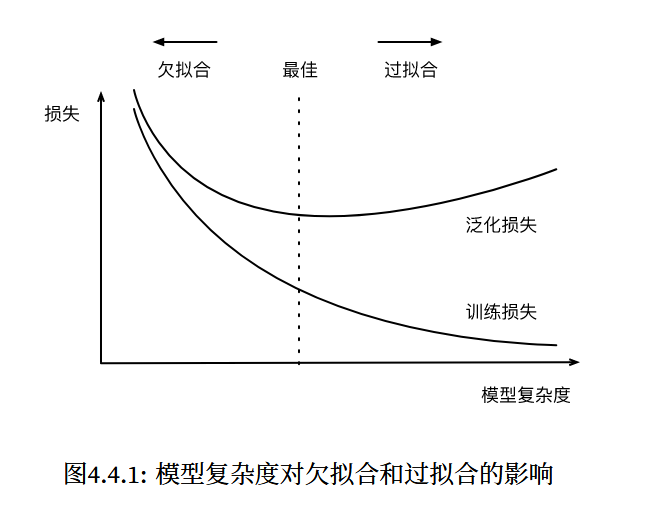

###数据集大小

训练数据集中的样本越少,我们就越有可能(且更严重地)过拟合。随着训练数据量的增加,泛化误差通常会减小。
此外,一般来说,更多的数据不会有什么坏处。对于固定的任务和数据分布,模型复杂性和数据集大小之间通常存在关系。
给出更多的数据,我们可能会尝试拟合一个更复杂的模型。能够拟合更复杂的模型可能是有益的。如果没有足够的数据,简单的模型可能更有用。

对于许多  任务,深度学习只有在有数千个训练样本时才优于线性模型。
从一定程度上来说,深度学习目前的生机要归功于廉价存储、互联设备以及数字化经济带来的海量数据集

##4.多项式回归

In [21]:
import math
import numpy as np
import torch
from torch import nn
from d2l import torch as d2l


In [22]:
# 1. 设置超参数
max_degree = 20          # 多项式的最大阶数（特征维度）
n_train, n_test = 100, 100  # 训练集和测试集的大小
true_w = np.zeros(max_degree)  # 分配 20 个权重的空间

# 2. 定义真实的模型参数（只有前4项有值，即：5 + 1.2x - 3.4x^2/2! + 5.6x^3/3!）
true_w[0:4] = np.array([5, 1.2, -3.4, 5.6])

# 3. 生成随机输入特征 x (形状: 200x1)
features = np.random.normal(size=(n_train + n_test, 1))
np.random.shuffle(features)

# 4. 生成多项式特征 (x^0, x^1, x^2, ..., x^19)
# 使用 np.power 进行广播计算
poly_features = np.power(features, np.arange(max_degree).reshape(1, -1))

# 5. 对每一项进行阶乘缩放（类似泰勒展开的每一项分母 i!）
for i in range(max_degree):
    poly_features[:, i] /= math.gamma(i + 1)  # math.gamma(n+1) 就是 n!

# 6. 生成标签 y (labels)
# y = Xw (矩阵乘法)
labels = np.dot(poly_features, true_w)

# 7. 添加随机噪声（均值为0，标准差为0.1的高斯噪声）
labels += np.random.normal(scale=0.1, size=labels.shape)

In [23]:
true_w, features, poly_features, labels = [torch.tensor(x, dtype=  torch.float32)
                                           for x in [true_w, features, poly_features, labels]]

In [24]:
def evaluate_loss(net, data_iter, loss):
    """评估给定数据集上模型的损失"""

    # 1. 初始化累加器：创建一个容量为 2 的容器
    # metric[0] 用于累加损失总和
    # metric[1] 用于累加样本总数
    metric = d2l.Accumulator(2)

    # 2. 将模型设置为评估模式（关闭 Dropout, Batch Normalization 等训练专用行为）
    if isinstance(net, torch.nn.Module):
        net.eval()

    # 3. 遍历数据集
    for X, y in data_iter:
        # 前向传播得到预测值
        out = net(X)

        # 确保标签 y 的维度与输出 out 一致，防止因维度自动广播导致计算错误
        y = y.reshape(out.shape)

        # 计算当前 batch 的损失
        l = loss(out, y)

        # l.sum() 将一个 batch 的损失加起来
        # l.numel() 返回该 batch 中样本的数量
        metric.add(l.sum(), l.numel())

    # 返回：平均损失 = 总损失 / 总样本数
    return metric[0] / metric[1]


from train_ch3 import train_epoch_ch3

def train(train_features, test_features, train_labels, test_labels, num_epochs=400):
    # 1. 定义损失函数：均方误差（MSE），使用 'none' 方便后续按样本手动求和/平均
    loss = nn.MSELoss(reduction='none')

    # 2. 获取输入维度（即多项式的阶数）
    input_shape = train_features.shape[-1]

    # 3. 定义模型：单层线性网络
    # 注意：bias=False。原因：我们在 poly_features 中已经包含了 x^0（常数项），
    # 线性层就不再需要额外的偏置项了。
    net = nn.Sequential(nn.Linear(input_shape, 1, bias=False))

    # 4. 准备数据迭代器
    batch_size = min(10, train_labels.shape[0])
    train_iter = d2l.load_array((train_features, train_labels.reshape(-1,1)), batch_size)
    test_iter = d2l.load_array((test_features, test_labels.reshape(-1,1)), batch_size, is_train=False)

    # 5. 定义优化器：随机梯度下降（SGD）
    trainer = torch.optim.SGD(net.parameters(), lr=0.01,weight_decay=0.01)#加入L2正则化weight_decay

    # 6. 初始化动画可视化器
    animator = d2l.Animator(xlabel='epoch', ylabel='loss', yscale='log',
                            xlim=[1, num_epochs], ylim=[1e-3, 1e2],
                            legend=['train', 'test'])

    # 7. 训练循环
    for epoch in range(num_epochs):
        # 训练一个周期（利用 d2l 封装好的函数）
        #d2l.train_epoch_ch3(net, train_iter, loss, trainer)  d2l中没有该函数
        train_epoch_ch3(net, train_iter, loss, trainer)

        # 周期性地（每20个周期）计算并记录损失值
        if epoch == 0 or (epoch + 1) % 20 == 0:
            animator.add(epoch + 1, (evaluate_loss(net, train_iter, loss),
                                     evaluate_loss(net, test_iter, loss)))

    # 8. 打印最终学习到的权重
    print('weight:', net[0].weight.data.numpy())

##三阶多项式函数拟合(正常)

weight: [[ 4.9648447  1.4282209 -3.3926847  5.007981 ]]


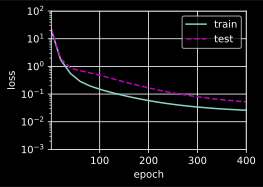

In [25]:
# 从多项式特征中选择前4个维度,即1,x,x^2/2!,x^3/3!
train(poly_features[:n_train, :4], poly_features[n_train:, :4],  labels[:n_train], labels[n_train:])

##线性函数拟合(欠拟合)

减少该模型的训练损失相对困难。在最后一个迭代周期完成后,训练损失仍然很高

weight: [[3.3263924 3.4209516]]


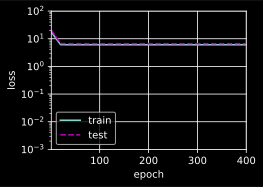

In [26]:
# 从多项式特征中选择前2个维度,即1和x
train(poly_features[:n_train, :2], poly_features[n_train:, :2],  labels[:n_train], labels[n_train:])

##高阶多项式函数拟合(过拟合)

weight: [[ 4.9056439e+00  1.4287198e+00 -3.0679398e+00  4.7842731e+00
  -1.0223519e+00  1.0446573e+00 -1.4910504e-01  1.2082075e-01
   2.6825735e-02  5.5110354e-02 -9.8742032e-03 -1.2971552e-02
   2.5173272e-03  4.0725481e-02  3.1050824e-02  2.1724498e-02
  -3.8070526e-04 -2.9027931e-02  1.1727866e-02  1.7296163e-02]]


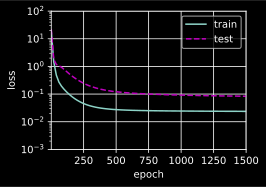

In [27]:
# 从多项式特征中选取所有维度
train(poly_features[:n_train, :], poly_features[n_train:, :],  labels[:n_train], labels[n_train:], num_epochs=1500)

欠拟合是指模型无法继续减少训练误差。过拟合是指训练误差远小于验证误差。

由于不能基于训练误差来估计泛化误差,因此简单地最小化训练误差并不一定意味着泛化误差的减小。
机器学习模型需要注意防止过拟合,即防止泛化误差过大。

验证集可以用于模型选择,但不能过于随意地使用它。
我们应该选择一个复杂度适当的模型,避免使用数量不足的训练样本。